##  Exercícios propostos

1. **Comparação entre cidades**: repita a análise para uma segunda cidade (ou um segundo bairro) e compare a tabela-resumo. Cidades com traçado em grade (ex.: bairros planejados) tendem a ter circuidade e resistance distance menores do que cidades com traçado orgânico/histórico?

2. **Efeito do raio da sub-rede**: refaça as Seções 9 a 13 variando o parâmetro `raio_m` (por exemplo, 500 m, 1500 m, 2000 m). Como a distância espectral média e a resistance distance média mudam com o tamanho da sub-rede? O que isso sugere sobre a escala em que essas medidas são mais informativas?

3. **Robustez da rede**: remova o nó de maior betweenness da rede completa e recalcule o comprimento médio de caminhos $\langle l \rangle$. O quanto ele aumenta? Repita removendo o nó de maior grau (do notebook anterior) para comparar qual tipo de nó é mais crítico para a conectividade global.

4. **Difusão em diferentes tempos**: calcule a distância de difusão para uma faixa mais ampla de valores de $t$ (por exemplo, $t = 0.1, 1, 10, 100$) e visualize como a correlação com a distância geodésica muda. Em que valor de $t$ a distância de difusão começa a "perder" a informação de distância local?

5. **Modos espectrais de frequência mais alta**: na Seção 9, visualizamos o vetor de Fiedler ($u_2$, o modo de mais baixa frequência não trivial). Refaça essa visualização para $u_3$, $u_4$ e um autovetor de índice bem mais alto (por exemplo, $u_{20}$). Os padrões espaciais ficam mais "finos" (com mais trocas de sinal) conforme o índice aumenta? Isso é consistente com a analogia de "filtro passa-baixa" discutida na Seção 11?

6. **Comparação topológica vs. geográfica**: refaça a Seção 14 (closeness) usando distância topológica (número de arestas) em vez de metros. Os nós de maior closeness mudam? O que isso revela sobre a diferença entre "central em número de cruzamentos" e "central em distância real percorrida"?

### 1. Configuração do ambiente

In [1]:
%pip install osmnx
import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd
import scipy
from scipy.sparse.csgraph import shortest_path as sp_shortest_path
from scipy.linalg import eigh
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 11
mpl.rcParams['axes.grid'] = True
mpl.rcParams['grid.alpha'] = 0.3

ox.settings.log_console = False
ox.settings.use_cache = True

np.random.seed(42)
print("Bibliotecas carregadas. Versão do OSMnx:", ox.__version__)


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\paulo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Bibliotecas carregadas. Versão do OSMnx: 2.1.1


### 2. Download das redes

#### 2.1 Rede completa da cidade

Baixamos a rede viária de São Carlos (tipo `drive`) e extraímos o **maior componente conectado**. Em redes reais, é comum existirem pequenos fragmentos desconectados (por exemplo, ruas dentro de um condomínio fechado sem outra ligação mapeada), e a maioria das medidas de distância exige que a rede seja conexa (caso contrário, a distância entre nós de componentes diferentes seria infinita).

In [2]:
lugar = "Barcelona, Spain"

G_osm = ox.graph_from_place(lugar, network_type="drive")
G_full_dir = ox.convert.to_undirected(G_osm)
G_full_raw = nx.Graph(G_full_dir)
# remove self-loops (arestas que ligam um no a ele mesmo)
G_full_raw.remove_edges_from(nx.selfloop_edges(G_full_raw))

# maior componente conectado
maior_componente = max(nx.connected_components(G_full_raw), key=len)
G_full = G_full_raw.subgraph(maior_componente).copy()

print(f"Rede completa (bruta):        N={G_full_raw.number_of_nodes()}, E={G_full_raw.number_of_edges()}")
print(f"Maior componente conectado:   N={G_full.number_of_nodes()}, E={G_full.number_of_edges()}")
print(f"Fração de nós no maior componente: {G_full.number_of_nodes()/G_full_raw.number_of_nodes():.3%}")

Rede completa (bruta):        N=8954, E=13993
Maior componente conectado:   N=8954, E=13993
Fração de nós no maior componente: 100.000%


#### 2.2 Sub-rede reduzida (campus da USP em São Carlos)

Para as medidas com custo computacional elevado (matrizes $N \times N$), extraímos uma sub-rede menor centrada no campus da USP em São Carlos, com raio de 1 km.

In [3]:
endereco_referencia = "L'Eixample, Barcelona, Spain"
#endereco_referencia = "Catedral, São Carlos, SP, Brasil"
raio_m = 2000

G_red_osm = ox.graph_from_address(endereco_referencia, dist=raio_m, network_type="drive")
G_red_dir = ox.convert.to_undirected(G_red_osm)
G_red_raw = nx.Graph(G_red_dir)
# remove self-loops
G_red_raw.remove_edges_from(nx.selfloop_edges(G_red_raw))

# extrai o maior componente conectado
maior_componente_red = max(nx.connected_components(G_red_raw), key=len)
G_red = G_red_raw.subgraph(maior_componente_red).copy()
G_red_osm_conectado = G_red_osm.subgraph(maior_componente_red).copy()

n_red = G_red.number_of_nodes()
print(f"L'Eixample, Barcelona, Spain (raio {raio_m} m): N={n_red}, E={G_red.number_of_edges()}")

if n_red > 1000:
    print("\nAVISO: a sub-rede está maior do que o recomendado para álgebra matricial densa (N>1000).")
    print("Considere diminuir 'raio_m' na célula acima.")
else:
    print("Tamanho adequado para as decomposições matriciais densas usadas mais adiante.")

L'Eixample, Barcelona, Spain (raio 2000 m): N=2009, E=3270

AVISO: a sub-rede está maior do que o recomendado para álgebra matricial densa (N>1000).
Considere diminuir 'raio_m' na célula acima.


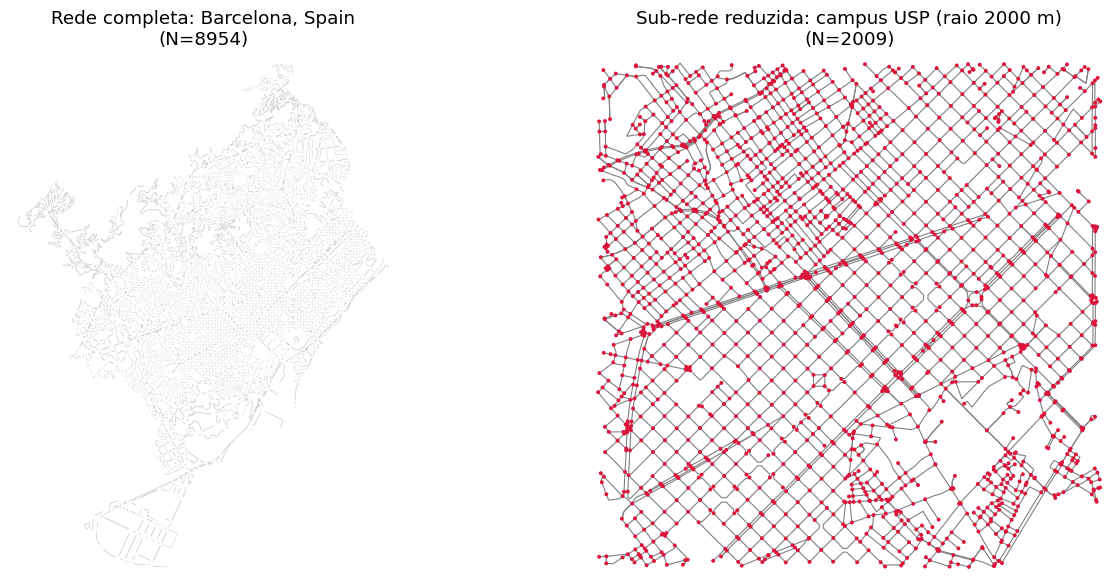

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ox.plot_graph(G_osm, ax=axes[0], node_size=2, edge_color="lightgray", edge_linewidth=0.4,
              bgcolor="white", show=False, close=False)
axes[0].set_title(f"Rede completa: {lugar}\n(N={G_full.number_of_nodes()})")

ox.plot_graph(G_red_osm_conectado, ax=axes[1], node_size=8, node_color="crimson",
              edge_color="gray", edge_linewidth=0.8, bgcolor="white", show=False, close=False)
axes[1].set_title(f"Sub-rede reduzida: campus USP (raio {raio_m} m)\n(N={n_red})")
plt.tight_layout()
plt.show()

## 3. Distância geodésica

A **distância geodésica** entre dois nós $i$ e $j$ é o comprimento do **caminho mais curto** que os liga na rede:

$$d(i,j) = \min_{\text{caminhos } i \to j} \sum_{(u,v) \in \text{caminho}} w(u,v)$$

Duas variantes são comuns:

- **Distância topológica (não ponderada)**: cada aresta tem peso 1, então $d(i,j)$ é simplesmente o **número de arestas** (hops) do caminho mais curto.
- **Distância geodésica ponderada**: cada aresta tem um peso real. No nosso caso, o comprimento físico do trecho de rua em metros (atributo `length`, calculado automaticamente pelo OSMnx a partir das coordenadas geográficas). Então $d(i,j)$ é a **menor distância percorrida em metros**.

Vamos ilustrar com um exemplo concreto: a rota mais curta entre dois pontos na sub-rede reduzida.

In [5]:
nos_lista = list(G_red_osm_conectado.nodes())
# define duas origens e destino arbitrários
origem, destino = nos_lista[0], nos_lista[len(nos_lista)//2]

dist_topologica = nx.shortest_path_length(G_red_osm_conectado, origem, destino)                  # em número de arestas
dist_geodesica_m = nx.shortest_path_length(G_red_osm_conectado, origem, destino, weight="length")  # em metros

rota = nx.shortest_path(G_red_osm_conectado, origem, destino, weight="length")

print(f"Nó de origem: {origem}   |   Nó de destino: {destino}")
print(f"Distância topológica (número de arestas): {dist_topologica}")
print(f"Distância geodésica ponderada:             {dist_geodesica_m:.1f} m")
print(f"Rota (sequência de nós):                   {len(rota)} nós no caminho")

Nó de origem: 21638874   |   Nó de destino: 243339565
Distância topológica (número de arestas): 39
Distância geodésica ponderada:             3102.2 m
Rota (sequência de nós):                   41 nós no caminho


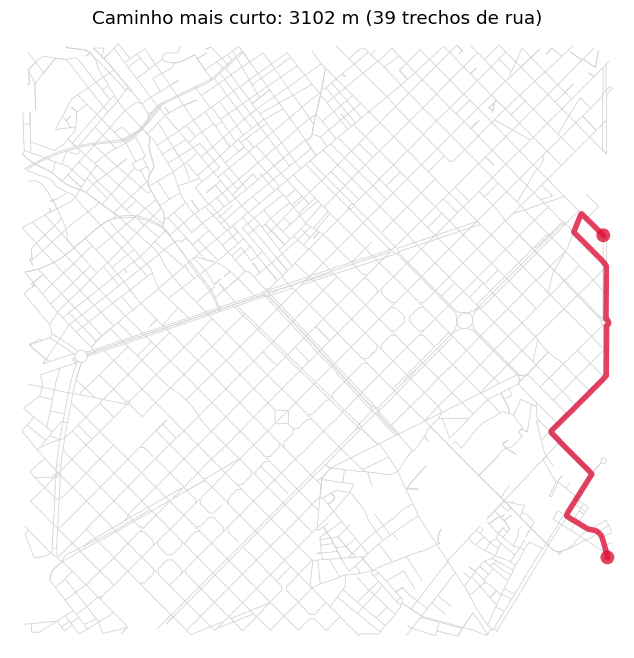

In [6]:
fig, ax = ox.plot_graph_route(
    G_red_osm_conectado, rota, route_color="crimson", route_linewidth=4, route_alpha=0.8,
    node_size=0, edge_color="lightgray", edge_linewidth=0.6, bgcolor="white",
    show=False, close=False
)
ax.set_title(f"Caminho mais curto: {dist_geodesica_m:.0f} m ({dist_topologica} trechos de rua)")
plt.show()

## 4. Matriz de distâncias par a par

Para as próximas seções, precisamos da **matriz de distâncias** completa $D$, em que $D_{ij}$ é a distância geodésica ponderada entre os nós $i$ e $j$. Calculamos essa matriz na **sub-rede reduzida** usando o algoritmo de Dijkstra (via `scipy.sparse.csgraph`), que é muito mais eficiente do que chamar `nx.shortest_path_length` par a par.

In [7]:
# Cria uma lista com todos os nós da sub-rede reduzida.
# A ordem desta lista será usada nas linhas e colunas das matrizes.
nos_red = list(G_red.nodes())

# Cria um dicionário que associa cada identificador de nó
# à sua posição correspondente nas matrizes.
idx_do_no = {no: i for i, no in enumerate(nos_red)}

# Armazena a quantidade total de nós da sub-rede.
n = len(nos_red)

# Converte o grafo em uma matriz de adjacência esparsa:
# - nodelist define a ordem dos nós;
# - weight="length" utiliza o comprimento das arestas como peso.
A_sparsa = nx.to_scipy_sparse_array(
    G_red,
    nodelist=nos_red,
    weight="length"
)

# Calcula as menores distâncias geodésicas entre todos os pares de nós.
# method="D" seleciona o algoritmo de Dijkstra;
# directed=False trata a rede como não direcionada.
# O resultado é uma matriz N × N, com as distâncias em metros.
D = sp_shortest_path(
    A_sparsa,
    method="D",
    directed=False
)

# Exibe as dimensões da matriz de distâncias.
print(f"Matriz de distâncias: {D.shape[0]} x {D.shape[1]}")

# Verifica se existem distâncias infinitas.
# Um resultado True indica que há pares de nós sem caminho entre eles.
print(
    f"Alguma distância infinita (desconexão)? "
    f"{np.isinf(D).any()}"
)

# Exibe a menor distância positiva da matriz.
# A condição D > 0 exclui a diagonal principal, cujos valores são zero.
print(
    f"Distância mínima (excluindo diagonal): "
    f"{D[D > 0].min():.2f} m"
)

# Exibe a maior distância geodésica encontrada na sub-rede.
print(f"Distância máxima: {D.max():.2f} m")

Matriz de distâncias: 2009 x 2009
Alguma distância infinita (desconexão)? False
Distância mínima (excluindo diagonal): 1.25 m
Distância máxima: 5847.76 m


## 5. Distribuição, momentos, variância e entropia das distâncias

Assim como fizemos com o grau, podemos tratar o conjunto de todas as distâncias par a par $\{D_{ij} : i<j\}$ como uma amostra de uma variável aleatória e caracterizá-la estatisticamente.

$$\langle d \rangle = \frac{1}{\binom{N}{2}}\sum_{i<j} D_{ij} \qquad
\langle d^2 \rangle = \frac{1}{\binom{N}{2}}\sum_{i<j} D_{ij}^2 \qquad
\langle d^3 \rangle = \frac{1}{\binom{N}{2}}\sum_{i<j} D_{ij}^3$$

$$\sigma_d^2 = \langle d^2 \rangle - \langle d \rangle^2$$

Como a distância é uma variável **contínua** (não discreta, como o grau), calculamos sua entropia discretizando os valores em faixas (bins) e aplicando a entropia de Shannon sobre o histograma normalizado:

$$H(D) = -\sum_{b} p_b \log_2 p_b$$

em que $p_b$ é a fração de pares de nós cuja distância cai na faixa $b$.

In [8]:
# Obtém os índices (i, j) da parte superior da matriz,
# considerando apenas pares com i < j e excluindo a diagonal principal.
# k=1 exclui a diagonal principal.
iu = np.triu_indices(n, k=1)  # pares i<j (parte superior, sem a diagonal)
# Seleciona de D as distâncias correspondentes a esses pares,
# gerando um vetor 1D sem a diagonal e sem pares duplicados.
distancias = D[iu]

media_d = distancias.mean()
m2_d = np.mean(distancias**2)
m3_d = np.mean(distancias**3)
var_d = distancias.var()
std_d = distancias.std()
cv_d = std_d / media_d

print(f"Número de pares de nós considerados: {len(distancias)}")
print(f"<d>   (distância média):   {media_d:.2f} m")
print(f"<d^2> (2º momento):        {m2_d:.2f}")
print(f"<d^3> (3º momento):        {m3_d:.2f}")
print(f"Variância das distâncias:  {var_d:.2f}")
print(f"Desvio padrão:             {std_d:.2f} m")
print(f"Coeficiente de variação:   {cv_d:.4f}")

Número de pares de nós considerados: 2017036
<d>   (distância média):   2474.23 m
<d^2> (2º momento):        7468881.47
<d^3> (3º momento):        25331202343.95
Variância das distâncias:  1347085.74
Desvio padrão:             1160.64 m
Coeficiente de variação:   0.4691


Entropia da distribuição de distâncias:  4.5649 bits (com 30 faixas)
Entropia máxima possível:                4.9069 bits
Entropia normalizada:                     0.9303


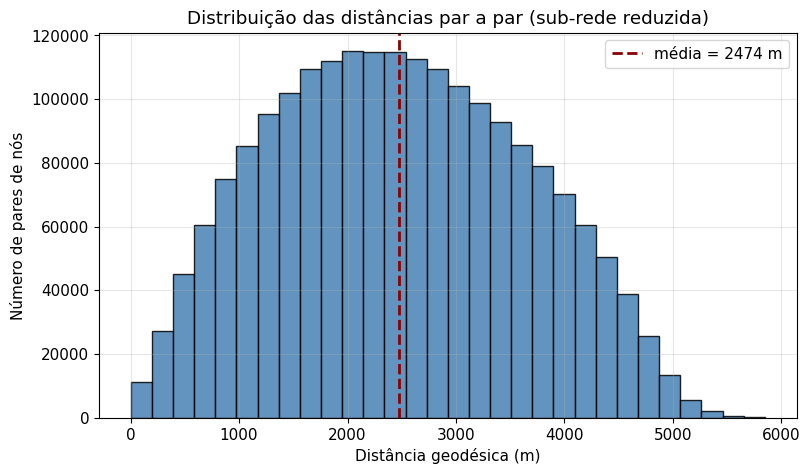

In [9]:
# Define o número de faixas (bins) usadas para dividir as distâncias.
n_bins = 30

# Calcula o histograma:
# - contagens_hist contém o número de distâncias em cada faixa;
# - bordas contém os limites de cada faixa.
contagens_hist, bordas = np.histogram(distancias, bins=n_bins)

# Converte as contagens em probabilidades, dividindo cada contagem
# pelo número total de distâncias.
p_bins = contagens_hist / contagens_hist.sum()

# Remove as faixas vazias, pois log2(0) é indefinido.
p_bins_nz = p_bins[p_bins > 0]

# Calcula a entropia de Shannon da distribuição das distâncias, em bits.
# Uma entropia maior indica que as distâncias estão mais distribuídas
# entre as diferentes faixas do histograma.
H_d = -np.sum(p_bins_nz * np.log2(p_bins_nz))

# Calcula a entropia máxima teórica para 30 faixas.
# Esse máximo ocorre quando todas as faixas possuem a mesma probabilidade.
H_d_max = np.log2(n_bins)

# Normaliza a entropia para o intervalo entre 0 e 1:
# - próximo de 0: distâncias concentradas em poucas faixas;
# - próximo de 1: distâncias distribuídas de forma mais uniforme.
H_d_norm = H_d / H_d_max

# Exibe a entropia calculada, em bits.
print(
    f"Entropia da distribuição de distâncias:  "
    f"{H_d:.4f} bits (com {n_bins} faixas)"
)

# Exibe a maior entropia possível para o número de faixas escolhido.
print(
    f"Entropia máxima possível:                "
    f"{H_d_max:.4f} bits"
)

# Exibe a entropia normalizada.
print(
    f"Entropia normalizada:                     "
    f"{H_d_norm:.4f}"
)

# Cria uma figura e um conjunto de eixos para o gráfico.
fig, ax = plt.subplots()

# Desenha o histograma das distâncias par a par.
ax.hist(
    distancias,
    bins=n_bins,
    color="steelblue",
    edgecolor="black",
    alpha=0.85
)

# Adiciona uma linha vertical indicando a distância média.
ax.axvline(
    media_d,
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"média = {media_d:.0f} m"
)

# Define o rótulo do eixo horizontal.
ax.set_xlabel("Distância geodésica (m)")

# Define o rótulo do eixo vertical.
ax.set_ylabel("Número de pares de nós")

# Define o título do gráfico.
ax.set_title(
    "Distribuição das distâncias par a par (sub-rede reduzida)"
)

# Exibe a legenda que identifica a linha da distância média.
ax.legend()

# Exibe o gráfico.
plt.show()

## 6. Distância média da rede e comprimento médio de caminhos

A **distância média da rede** é o mesmo $\langle d \rangle$ calculado acima, isto é, a média de todas as distâncias geodésicas ponderadas (em metros) entre pares de nós.

Já o **comprimento médio de caminhos** (*average path length*, $\langle \ell \rangle$), na definição clássica da literatura de redes complexas, usa a distância **topológica** (número de arestas, sem considerar o comprimento físico das ruas):

$$\langle \ell \rangle = \frac{1}{\binom{N}{2}} \sum_{i<j} \ell(i,j)$$

em que $\ell(i,j)$ é o número mínimo de arestas entre $i$ e $j$. Essa é a medida usada, por exemplo, para comparar redes "mundo pequeno" (small-world) com redes aleatórias.

Vamos calcular $\langle \ell \rangle$ na **rede completa** (viável, pois não requer montar a matriz $N \times N$ inteira. O NetworkX faz isso de forma eficiente por BFS a partir de cada nó).

In [10]:
N_full = G_full.number_of_nodes()
LIMITE_EXATO = 5000  # acima disso, usamos amostragem para estimar <l>

if N_full <= LIMITE_EXATO:
    l_medio = nx.average_shortest_path_length(G_full)  # topológico (hops)
    metodo = "exato (todos os pares)"
else:
    # estimativa por amostragem: BFS a partir de um subconjunto aleatório de nós
    amostra = np.random.choice(list(G_full.nodes()), size=300, replace=False)
    somas, contagens_pares = 0, 0
    for no in amostra:
        comprimentos = nx.single_source_shortest_path_length(G_full, no)
        somas += sum(comprimentos.values())
        contagens_pares += len(comprimentos) - 1  # exclui o próprio nó
    l_medio = somas / contagens_pares
    metodo = "estimado por amostragem (300 nós de origem)"

print(f"Comprimento médio de caminhos <l> (topológico, rede completa): {l_medio:.3f} arestas")
print(f"Método: {metodo}")

media_d_reduzida_topologica = nx.average_shortest_path_length(G_red)  # comparação, na sub-rede
print(f"\nPara comparação, na sub-rede reduzida:")
print(f"  <l> topológico:            {media_d_reduzida_topologica:.3f} arestas")
print(f"  <d> geodésico (metros):    {media_d:.2f} m")

Comprimento médio de caminhos <l> (topológico, rede completa): 39.046 arestas
Método: estimado por amostragem (300 nós de origem)

Para comparação, na sub-rede reduzida:
  <l> topológico:            25.567 arestas
  <d> geodésico (metros):    2474.23 m


## 7. Diâmetro, raio, centro, periferia e excentricidade

A **excentricidade** de um nó $i$ é a distância até o nó mais afastado dele na rede:

$$e(i) = \max_j d(i,j)$$

A partir das excentricidades de todos os nós, definimos:

- **Diâmetro**: $\text{diam}(G) = \max_i e(i)$: a maior distância entre quaisquer dois nós da rede (o "pior caso" de distância).
- **Raio**: $\text{raio}(G) = \min_i e(i)$: a menor excentricidade da rede.
- **Centro**: conjunto de nós com $e(i) = \text{raio}(G)$: os nós "mais centrais" no sentido geométrico (minimizam a pior distância).
- **Periferia**: conjunto de nós com $e(i) = \text{diam}(G)$: os nós nos "extremos" da rede.

Calcular a excentricidade **exata** de todos os nós exige BFS a partir de cada um deles, o mesmo custo do comprimento médio de caminhos. Fazemos isso de forma exata na sub-rede reduzida, e usamos uma aproximação eficiente (heurística de "duplo alcance"/2-sweep) para a rede completa.

In [11]:
# Sub-rede reduzida: exato, com distâncias ponderadas (metros)
excentricidades_red = {nos_red[i]: D[i].max() for i in range(n)}
diametro_red = max(excentricidades_red.values())
raio_red = min(excentricidades_red.values())
centro_red = [no for no, e in excentricidades_red.items() if np.isclose(e, raio_red)]
periferia_red = [no for no, e in excentricidades_red.items() if np.isclose(e, diametro_red)]

print("=== Sub-rede reduzida (distâncias em metros) ===")
print(f"Diâmetro: {diametro_red:.1f} m")
print(f"Raio:     {raio_red:.1f} m")
print(f"Número de nós no centro:    {len(centro_red)}")
print(f"Número de nós na periferia: {len(periferia_red)}")

=== Sub-rede reduzida (distâncias em metros) ===
Diâmetro: 5847.8 m
Raio:     3050.5 m
Número de nós no centro:    1
Número de nós na periferia: 2


In [12]:
# Rede completa: diâmetro exato ou aproximado, conforme o tamanho
if N_full <= LIMITE_EXATO:
    diametro_full = nx.diameter(G_full)
    raio_full = nx.radius(G_full)
    metodo_diam = "exato"
else:
    diametro_full = nx.approximation.diameter(G_full, seed=42)  # heurística 2-sweep (limite inferior)
    raio_full = None
    metodo_diam = "aproximado (heurística 2-sweep; é um limite inferior do diâmetro real)"

print("=== Rede completa (distância topológica, em número de arestas) ===")
print(f"Diâmetro: {diametro_full}  [{metodo_diam}]")
if raio_full is not None:
    print(f"Raio:     {raio_full}")

=== Rede completa (distância topológica, em número de arestas) ===
Diâmetro: 92  [aproximado (heurística 2-sweep; é um limite inferior do diâmetro real)]


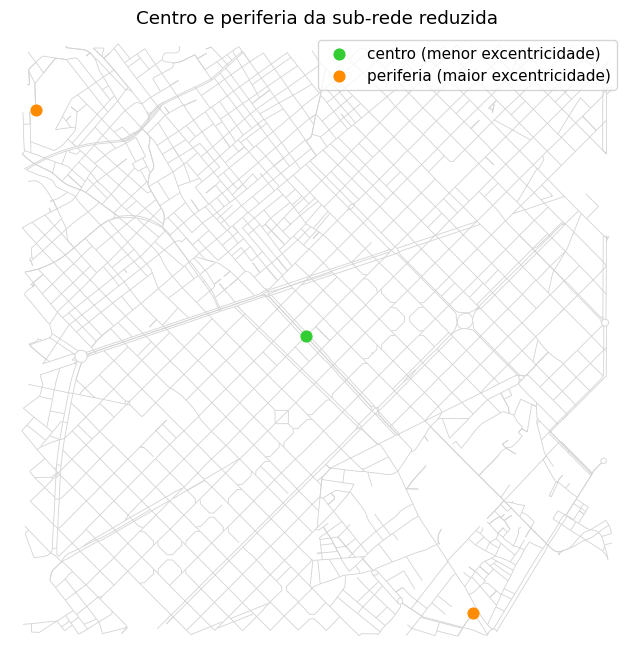

In [13]:
fig, ax = ox.plot_graph(G_red_osm_conectado, node_size=0, edge_color="lightgray", edge_linewidth=0.6,
                         bgcolor="white", show=False, close=False)

xs_centro = [G_red.nodes[n_]['x'] for n_ in centro_red]
ys_centro = [G_red.nodes[n_]['y'] for n_ in centro_red]
xs_perif = [G_red.nodes[n_]['x'] for n_ in periferia_red]
ys_perif = [G_red.nodes[n_]['y'] for n_ in periferia_red]

ax.scatter(xs_centro, ys_centro, c="limegreen", s=60, label="centro (menor excentricidade)", zorder=5)
ax.scatter(xs_perif, ys_perif, c="darkorange", s=60, label="periferia (maior excentricidade)", zorder=5)
ax.legend(loc="upper right")
ax.set_title("Centro e periferia da sub-rede reduzida")
plt.show()

## 8. Eficiência da rede

A **eficiência global** (Latora & Marchiori, 2001) mede o quão eficientemente a informação circula pela rede, usando o **inverso** das distâncias: pares muito distantes contribuem pouco, pares próximos contribuem muito:

$$E_{glob} = \frac{1}{N(N-1)} \sum_{i \neq j} \frac{1}{d(i,j)}$$

$E_{glob}$ varia entre 0 (rede desconexa) e 1 (rede completa, todos os nós ligados diretamente). É particularmente útil porque, diferente da distância média, permanece bem definida mesmo se a rede for desconexa (pares infinitamente distantes contribuem 0, em vez de "quebrar" a média).

A **eficiência local** de um nó $i$ mede a eficiência da sub-rede formada pelos vizinhos de $i$ (sem contar $i$): uma espécie de "tolerância a falhas" local, ou seja, o quão bem os vizinhos de $i$ se comunicariam entre si caso $i$ fosse removido.

$$E_{loc} = \frac{1}{N}\sum_i E_{glob}(\mathcal{N}(i))$$

In [14]:
eficiencia_global_full = nx.global_efficiency(G_full)     # topológica, rede completa
eficiencia_global_red = nx.global_efficiency(G_red)       # topológica, sub-rede
eficiencia_local_red = nx.local_efficiency(G_red)         # sub-rede (mais custosa)

print(f"Eficiência global (rede completa, topológica): {eficiencia_global_full:.5f}")
print(f"Eficiência global (sub-rede reduzida):          {eficiencia_global_red:.5f}")
print(f"Eficiência local  (sub-rede reduzida):           {eficiencia_local_red:.5f}")

Eficiência global (rede completa, topológica): 0.03359
Eficiência global (sub-rede reduzida):          0.05550
Eficiência local  (sub-rede reduzida):           0.04126


## 9. Fundamentos espectrais: Laplaciano, autovalores e autovetores

As próximas cinco seções (9 a 13) vamos estudar medidas espectrais: um conjunto de medidas de distância que não olham apenas para o "melhor" caminho entre dois nós (como a distância geodésica), mas para a **estrutura global** da rede, capturada pelos autovalores e autovetores de uma matriz especial chamada **Laplaciano**.

Essa ideia vem da chamada **teoria espectral de grafos** (*spectral graph theory*), que também está por trás de técnicas amplamente usadas em ciência de dados, como *clustering* espectral, *embeddings* de grafos e redução de dimensionalidade em redes.

O **Laplaciano combinatorial** de um grafo é definido como
$$L = D - A$$
em que $D$ é a matriz diagonal de graus (com $D_{ii} = k_i$) e $A$ é a matriz de adjacência. Por exemplo, para um nó $i$ com vizinhos $j_1, j_2, j_3$, a linha $i$ de $L$ tem $k_i$ na diagonal e $-1$ nas colunas correspondentes a $j_1, j_2, j_3$ (e 0 nas demais).

Essa construção pode parecer arbitrária à primeira vista, mas tem uma propriedade fundamental: para **qualquer** vetor $x \in \mathbb{R}^N$ (pense em $x$ como um valor associado a cada nó, um "sinal" na rede),
$$x^{\top} L x = \sum_{(i,j) \in E} (x_i - x_j)^2 \;\geq\; 0$$

Ou seja, $x^\top L x$ mede o quanto o sinal $x$ "varia" entre nós vizinhos. Quanto mais suave (parecido entre vizinhos) for $x$, menor esse valor. Essa propriedade garante que $L$ é **simétrica e semidefinida positiva**, o que por sua vez garante que todos os seus autovalores são reais e não-negativos, e que existe uma base ortonormal completa de autovetores. Para um grafo conexo, a decomposição espectral é:

$$L = U \Lambda U^{\top}, \qquad \Lambda = \text{diag}(\lambda_1, \dots, \lambda_N), \quad 0 = \lambda_1 < \lambda_2 \leq \dots \leq \lambda_N$$

em que $u_k$ (colunas de $U$) são os autovetores ortonormais e $\lambda_k$ os autovalores, ordenados do menor para o maior.

**Por que o menor autovalor é sempre zero?**

Para o vetor constante $x = (1, 1, \dots, 1)^\top$, cada termo $(x_i - x_j)^2$ da soma acima é zero (afinal, $x_i = x_j = 1$ para toda aresta). Logo $x^\top L x = 0$, e esse vetor constante é sempre um autovetor de $L$ associado ao autovalor $\lambda_1 = 0$. Ele não carrega nenhuma informação estrutural (não distingue nós entre si), então será descartado nas distâncias espectrais definidas mais adiante.

Um resultado ainda mais forte (que não provaremos aqui, mas vale conhecer): **a multiplicidade do autovalor 0 é igual ao número de componentes conexas do grafo.** Como estamos sempre trabalhando com o maior componente conectado, esperamos observar $\lambda_1 = 0$ com multiplicidade exatamente 1. Vamos verificar isso na prática já na próxima célula.

**O segundo autovalor e o vetor de Fiedler**

O segundo autovalor, $\lambda_2$, tem um nome especial: **conectividade algébrica**. Ele mede, de forma indireta, o quão "difícil" é desconectar o grafo em dois pedaços:

- $\lambda_2$ **próximo de zero** sugere que a rede está perto de se dividir em dois grupos fracamente conectados (um "gargalo" estrutural, poucas arestas ligando duas metades da rede).
- $\lambda_2$ **grande** indica uma rede bem conectada, sem gargalos evidentes, difícil de fragmentar removendo poucas arestas.

O autovetor associado, $u_2$, é chamado de **vetor de Fiedler**, em homenagem ao matemático Miroslav Fiedler. Ele tem uma propriedade importante: os valores de $u_2$ tendem a ser parecidos (mesmo sinal, magnitude próxima) para nós que estão na mesma "região" da rede, e a mudar de sinal exatamente onde a rede é mais "estreita". Por isso, o vetor de Fiedler é a base do **particionamento espectral** (*spectral bisection*): basta separar os nós em dois grupos, conforme o sinal de $u_2$, para obter uma partição da rede em duas partes bem conectadas internamente e fracamente conectadas entre si. Vamos visualizar isso diretamente no mapa da nossa sub-rede, logo após calcularmos a decomposição espectral.

**Uma família de distâncias espectrais**

A partir da decomposição espectral do Laplaciano, definimos uma **família de distâncias espectrais** entre nós:

$$d_\varphi(i,j)^2 = \sum_{k=2}^{N} \varphi(\lambda_k)\,\big(u_k(i) - u_k(j)\big)^2$$

em que $\varphi(\cdot)$ é uma função-peso que decide **como** cada modo espectral (cada "frequência" da rede) contribui para a distância. A soma começa em $k=2$ porque, como vimos, o primeiro modo ($k=1$, autovalor 0) não carrega informação estrutural. Diferentes escolhas de $\varphi$ recuperam exatamente as três medidas das próximas seções:

| $\varphi(\lambda)$ | Medida resultante | Intuição |
|---|---|---|
| $1$ (constante) | Distância espectral simples (*embedding* Laplaciano) | Todos os modos pesam igual |
| $1/\lambda$ | Resistance Distance | Modos de baixa frequência (λ pequeno) pesam mais |
| $e^{-2t\lambda}$ | Distância de difusão (heat kernel) no "tempo" $t$ | Suprime modos de alta frequência, com intensidade controlada por $t$ |

Note o padrão: quanto menor o autovalor $\lambda_k$, mais peso ele recebe em duas das três medidas (resistência e difusão). Isso faz sentido, pois autovalores pequenos estão associados a modos de "larga escala" da rede (como a divisão de Fiedler descrita acima), enquanto autovalores grandes capturam variações locais, de curto alcance. As medidas espectrais de distância, portanto, tendem a enfatizar a posição de um nó na **estrutura macroscópica** da rede, e não apenas seus vizinhos imediatos.

In [15]:
# Calcula a matriz Laplaciana combinatorial da sub-rede reduzida.
# A ordem dos nos segue a lista "nos_red", garantindo consistencia
# com as outras matrizes do código (D, A_sparsa, etc.).
# Em seguida, converte a matriz esparsa para um array denso de floats,
# necessario para a decomposicao espectral com scipy.linalg.eigh.
L_red = (
    nx.laplacian_matrix(G_red, nodelist=nos_red)
    .toarray()
    .astype(float)
)

# Calcula os autovalores e autovetores da matriz Laplaciana.
# Como o Laplaciano e uma matriz real e simetrica, utiliza-se eigh()
# (mais rápido e numericamente mais estável do que o eig() genérico).
# Os autovalores são retornados em ordem crescente, e autovetores[:, k]
# e o autovetor associado a autovalores[k].
autovalores, autovetores = eigh(L_red)

# Exibe os cinco menores autovalores.
# Em um grafo conexo, o primeiro autovalor deve ser aproximadamente zero
# e possuir multiplicidade igual a 1 (ou seja, o segundo autovalor,
# a conectividade algebrica, deve ser estritamente positivo).
print(
    f"Menores 5 autovalores do Laplaciano: "
    f"{np.round(autovalores[:5], 6)}"
)

# Informa a interpretacao esperada para o menor autovalor.
print(
    "(o menor deveria ser ~0, confirmando que a sub-rede e conexa;"
    " o segundo, lambda_2, e a conectividade algebrica da rede)"
)

# Exibe o maior autovalor do Laplaciano.
print(f"Maior autovalor: {autovalores[-1]:.4f}")

# Descarta o primeiro autovalor, associado ao modo trivial lambda_1 = 0.
# Os valores restantes representam os modos espectrais não triviais.
lambdas = autovalores[1:]

# Descarta tambem o autovetor associado ao modo trivial.
# Cada coluna de U corresponde a um autovetor: u_2, u_3, ..., u_N.
# Note que, apos esse corte, "lambdas[0]" e "U[:, 0]" correspondem
# exatamente a lambda_2 e ao vetor de Fiedler u_2, descritos na teoria acima.
U = autovetores[:, 1:]

# Exibe o número de modos espectrais não triviais utilizados.
# Para uma rede conexa com N nós, esse número deve ser N - 1.
print(
    f"\nNúmero de modos espectrais não triviais utilizados: "
    f"{len(lambdas)}"
)

print(f"\nConectividade algebrica (lambda_2): {lambdas[0]:.6f}")

Menores 5 autovalores do Laplaciano: [0.       0.002675 0.004184 0.005672 0.010824]
(o menor deveria ser ~0, confirmando que a sub-rede e conexa; o segundo, lambda_2, e a conectividade algebrica da rede)
Maior autovalor: 7.8781

Número de modos espectrais não triviais utilizados: 2008

Conectividade algebrica (lambda_2): 0.002675


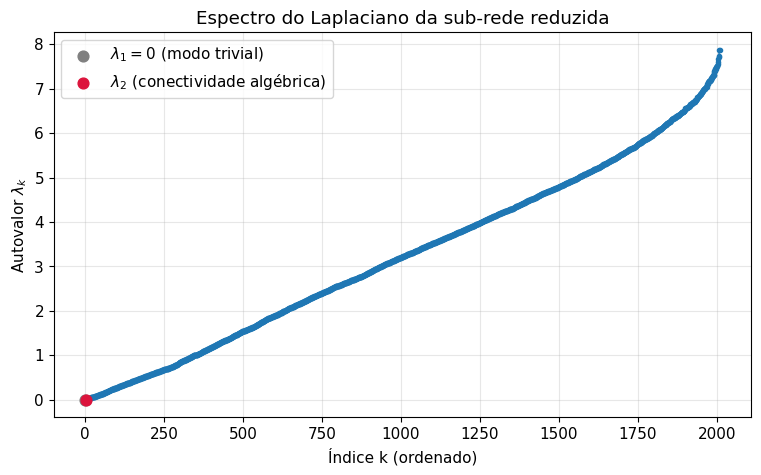

In [16]:
fig, ax = plt.subplots()
ax.plot(range(1, len(autovalores)+1), autovalores, marker="o", markersize=3, linewidth=1)
# destaca lambda_1 (modo trivial) e lambda_2 (conectividade algebrica)
ax.scatter([1], [autovalores[0]], color="gray", s=60, zorder=5, label=r"$\lambda_1 = 0$ (modo trivial)")
ax.scatter([2], [autovalores[1]], color="crimson", s=60, zorder=5, label=r"$\lambda_2$ (conectividade algébrica)")
ax.set_xlabel("Índice k (ordenado)")
ax.set_ylabel(r"Autovalor $\lambda_k$")
ax.set_title("Espectro do Laplaciano da sub-rede reduzida")
ax.legend()
plt.show()

**Como ler esse gráfico:** cada ponto é um autovalor do Laplaciano, ordenado do menor para o maior. Redes com muitos "grupos" bem definidos (comunidades fracamente conectadas entre si) costumam apresentar vários autovalores pequenos logo no início do espectro, seguidos de um salto (*gap* espectral) até valores maiores. Cada autovalor pequeno adicional sinaliza mais uma possível divisão natural da rede. Em uma malha viária urbana, tipicamente bem conectada e sem grandes barreiras físicas, esperamos ver o espectro crescer de forma relativamente suave, sem grandes saltos, refletindo a ausência de "gargalos" estruturais óbvios.

### Visualizando o vetor de Fiedler no mapa

Vamos agora colorir os nós da sub-rede de acordo com o **sinal** do vetor de Fiedler ($u_2$), a coluna `U[:, 0]` calculada acima. Se a teoria se confirmar, devemos observar uma separação espacialmente coerente da rede em duas regiões.

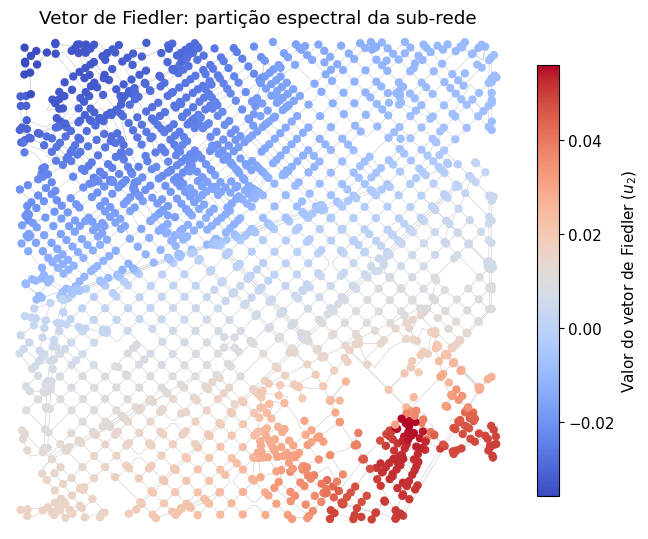

Nós com u_2 > 0: 927  |  Nós com u_2 < 0: 1082


In [17]:
# O vetor de Fiedler e a primeira coluna de U, pois descartamos o modo trivial
# (u_2 na notacao teorica corresponde ao indice 0 apos o corte).
fiedler = U[:, 0]

fig, ax = ox.plot_graph(G_red_osm_conectado, node_size=0, edge_color="lightgray", edge_linewidth=0.5,
                         bgcolor="white", show=False, close=False)

xs_fiedler = [G_red.nodes[no]['x'] for no in nos_red]
ys_fiedler = [G_red.nodes[no]['y'] for no in nos_red]

# Colorimos por valor contínuo (não apenas o sinal), o que revela também
# gradacoes dentro de cada "lado" da particao espectral.
sc = ax.scatter(xs_fiedler, ys_fiedler, c=fiedler, cmap="coolwarm", s=25, zorder=5)
plt.colorbar(sc, ax=ax, label="Valor do vetor de Fiedler ($u_2$)", shrink=0.7)
ax.set_title("Vetor de Fiedler: partição espectral da sub-rede")
plt.show()

n_positivos = np.sum(fiedler > 0)
n_negativos = np.sum(fiedler < 0)
print(f"Nós com u_2 > 0: {n_positivos}  |  Nós com u_2 < 0: {n_negativos}")

Se a rede tiver alguma estrutura espacial clara (por exemplo, duas regiões ligadas por poucas ruas, ou separadas por uma via arterial, um rio ou uma linha férrea), o mapa acima tende a mostrar essa divisão de forma bastante nítida: uma região predominantemente azul e outra predominantemente vermelha, com a transição ocorrendo justamente na "fronteira" estrutural da rede. Esse é o mesmo princípio usado em algoritmos de *clustering* espectral para particionar redes maiores em comunidades.

## 10. Distância espectral

Usando $\varphi(\lambda) = 1$ (peso constante, igual para todos os modos) na fórmula geral da seção anterior, obtemos a **distância espectral simples**: a distância Euclidiana entre os nós no espaço definido pelos autovetores não triviais do Laplaciano, isto é, um "*embedding* espectral" da rede, também chamado de mapa de Laplace (*Laplacian eigenmap*).

$$d_{spec}(i,j)^2 = \sum_{k=2}^{N} \big(u_k(i) - u_k(j)\big)^2 = \|U_i - U_j\|^2$$

em que $U_i$ é a $i$-ésima linha da matriz $U$: o vetor formado pelas coordenadas do nó $i$ em cada um dos $N-1$ autovetores não triviais.

Essa é uma forma natural de "posicionar" os nós em um espaço geométrico que preserva a estrutura da rede: nós que são estruturalmente parecidos (muitos caminhos curtos entre si, posições simétricas na rede) ficam próximos nesse espaço, mesmo que não sejam vizinhos diretos. É exatamente a mesma ideia por trás de técnicas de redução de dimensionalidade como o *Laplacian Eigenmap*, usadas em aprendizado de máquina para visualizar dados de alta dimensão.

Na prática, usamos apenas os autovetores associados aos **menores** autovalores não triviais para aproximar essa distância com poucas dimensões (assim como fazemos ao usar apenas as duas ou três primeiras componentes principais em uma PCA) — quanto menor o autovalor, mais "informação estrutural de larga escala" aquele modo carrega, como discutido na Seção 9.

In [18]:
def distancia_espectral(U, pesos):
    # Calcula a matriz de distancias espectrais D_phi(i,j) para uma dada
    # ponderação 'pesos' (um valor por autovalor não trivial, na mesma
    # ordem das colunas de U). Este e o "motor" reutilizado nas Secoes
    # 10 (pesos=1), 11 (pesos=exp(-2*t*lambda)) e 12 (pesos=1/lambda).
    #
    # A formula direta seria D2[i,j] = sum_k pesos[k] * (U[i,k] - U[j,k])**2,
    # mas calcular isso par a par seria lento (loop duplo em Python).
    # Em vez disso, usamos a identidade algebrica:
    #   ||a - b||^2 = ||a||^2 + ||b||^2 - 2 * <a, b>
    # que permite calcular TODAS as distancias de uma vez, via operacoes
    # matriciais vetorizadas (muito mais rápido).
    Up = U * np.sqrt(pesos)            # cada coluna k escalada por sqrt(peso_k)
    G_gram = Up @ Up.T                 # matriz de produtos internos <Up_i, Up_j>
    normas2 = np.diag(G_gram)          # ||Up_i||^2 para cada no i
    D2 = normas2[:, None] + normas2[None, :] - 2 * G_gram  # ||Up_i - Up_j||^2, para todo par
    D2 = np.clip(D2, 0, None)          # corrige erros numericos residuais (valores levemente negativos)
    return np.sqrt(D2)

# Distância espectral simples: pesos iguais a 1 para todos os modos não triviais
D_spectral = distancia_espectral(U, np.ones_like(lambdas))

print(f"Distância espectral média entre pares de nós: {D_spectral[iu].mean():.4f}")
print(f"Distância espectral máxima:                    {D_spectral[iu].max():.4f}")

# correlacao entre distancia espectral e distancia geodesica (em metros)
correlacao_spec_geo = np.corrcoef(D_spectral[iu], distancias)[0, 1]
print(f"Correlação (Pearson) entre distância espectral e distância geodésica: {correlacao_spec_geo:.4f}")

Distância espectral média entre pares de nós: 1.4142
Distância espectral máxima:                    1.4142
Correlação (Pearson) entre distância espectral e distância geodésica: -0.0629


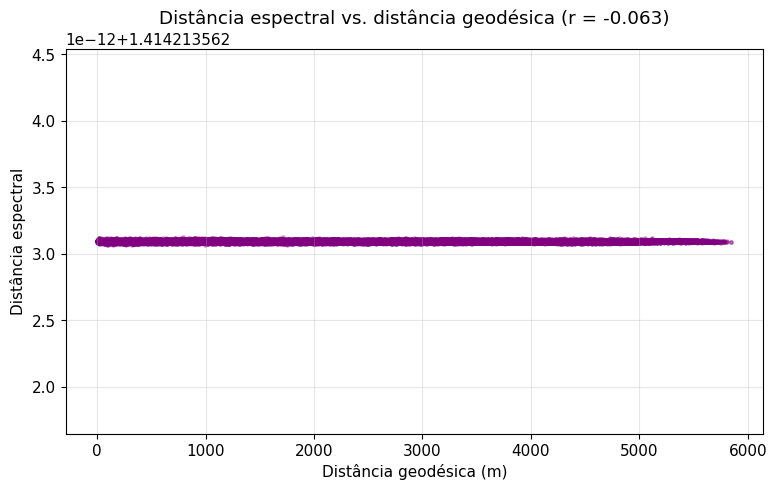

In [19]:
fig, ax = plt.subplots()
ax.scatter(distancias, D_spectral[iu], s=6, alpha=0.3, color="purple")
ax.set_xlabel("Distância geodésica (m)")
ax.set_ylabel("Distância espectral")
ax.set_title(f"Distância espectral vs. distância geodésica (r = {correlacao_spec_geo:.3f})")
plt.show()

**Interpretando a correlação:** uma correlação positiva forte indicaria que a distância espectral, calculada inteiramente a partir da álgebra do Laplaciano (sem nenhuma noção explícita de "caminho"), consegue recuperar bem a noção intuitiva de distância geodésica. Correlações mais moderadas são esperadas e não indicam um erro: a distância espectral captura uma noção mais ampla de similaridade estrutural (posição relativa na rede como um todo), que pode divergir da distância geodésica exatamente nos casos mais interessantes. Por exemplo, dois nós fisicamente distantes, mas que ocupam papéis estruturalmente equivalentes na rede (como dois pontos "de fronteira" em lados opostos da mesma partição de Fiedler) podem ter distância espectral menor do que sua distância geodésica sugeriria.

### Um *embedding* espectral em duas dimensões

Podemos visualizar diretamente a rede no "espaço espectral", usando apenas os dois primeiros modos não triviais ($u_2$, o vetor de Fiedler, e $u_3$) como coordenadas $(x, y)$ de cada nó. Colorimos os pontos pela posição geográfica real (coordenada leste-oeste) apenas para facilitar a comparação visual com o mapa real.

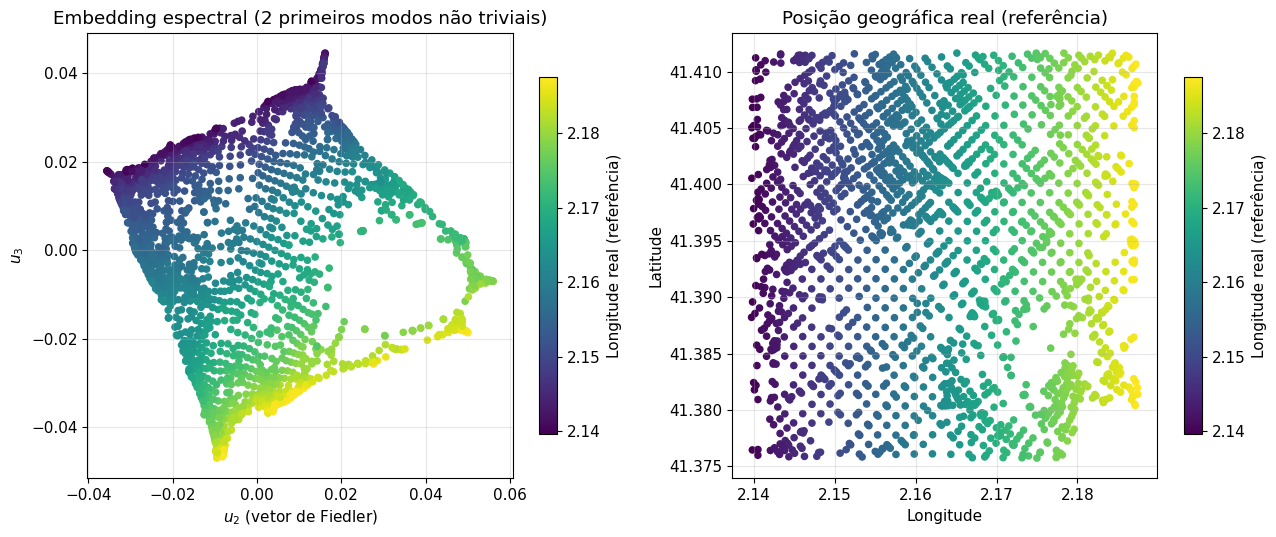

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# --- Painel 1: embedding espectral (coordenadas = autovetores u_2 e u_3) ---
u2, u3 = U[:, 0], U[:, 1]
xs_geo = np.array([G_red.nodes[no]['x'] for no in nos_red])  # usada so para colorir

sc1 = axes[0].scatter(u2, u3, c=xs_geo, cmap="viridis", s=20)
axes[0].set_xlabel(r"$u_2$ (vetor de Fiedler)")
axes[0].set_ylabel(r"$u_3$")
axes[0].set_title("Embedding espectral (2 primeiros modos não triviais)")
plt.colorbar(sc1, ax=axes[0], label="Longitude real (referência)", shrink=0.8)

# --- Painel 2: mapa geografico real, para comparacao, com a mesma cor de referencia ---
ys_geo = np.array([G_red.nodes[no]['y'] for no in nos_red])
sc2 = axes[1].scatter(xs_geo, ys_geo, c=xs_geo, cmap="viridis", s=20)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_title("Posição geográfica real (referência)")
plt.colorbar(sc2, ax=axes[1], label="Longitude real (referência)", shrink=0.8)

plt.tight_layout()
plt.show()

Ainda que o *embedding* espectral (painel esquerdo) não seja uma reprodução exata do mapa geográfico (painel direito), afinal, ele é construído inteiramente a partir da topologia da rede, sem nenhuma informação de coordenadas , é comum observar uma correspondência qualitativa entre os dois: a ordem relativa dos nós ao longo do eixo $u_2$ costuma acompanhar, ainda que de forma distorcida, a disposição espacial real da rede. Isso ilustra um fato notável da teoria espectral de grafos: para redes espaciais (como uma malha viária), *a topologia por si só já carrega bastante informação sobre a geometria*.

## 11. Distância de difusão

A **distância de difusão** (Coifman & Lafon, 2006) usa $\varphi(\lambda) = e^{-2t\lambda}$, em que $t$ é um "tempo de difusão". A intuição por trás dela vem de imaginar uma gota de tinta se espalhando pela rede através de um passeio aleatório: a distância de difusão mede o quanto as distribuições de probabilidade de encontrar essa tinta, após um tempo $t$, partindo de $i$ e partindo de $j$, diferem entre si.

$$d_t(i,j)^2 = \sum_{k=2}^{N} e^{-2t\lambda_k}\,\big(u_k(i) - u_k(j)\big)^2$$

O parâmetro $t$ funciona como uma espécie de "controle de zoom" sobre a estrutura da rede:

- Para **$t$ pequeno**, o fator $e^{-2t\lambda_k}$ é próximo de 1 para praticamente todos os modos (mesmo os de $\lambda_k$ grande), então quase todos os autovalores contribuem quase igualmente — a difusão ainda não teve tempo de "suavizar" as diferenças locais, e a distância de difusão se aproxima da estrutura local e fina da rede (parecida com a distância espectral simples da Seção 10).
- Para **$t$ grande**, o fator $e^{-2t\lambda_k}$ decai exponencialmente mais rápido para os $\lambda_k$ grandes do que para os pequenos. Assim, apenas os modos de baixa frequência (autovalores pequenos, que capturam a estrutura de larga escala/comunidades, como discutido na Seção 9) sobrevivem — os modos de alta frequência são exponencialmente suprimidos, revelando a organização macroscópica da rede.

Em outras palavras: aumentar $t$ tem o mesmo efeito, sobre o espectro do Laplaciano, que um filtro passa-baixa tem sobre um sinal — ele deixa passar apenas as variações "lentas" (de larga escala) e elimina as variações "rápidas" (de curta escala, entre vizinhos próximos).

In [21]:
tempos_difusao = [1, 5, 20]
distancias_difusao = {}

# Para cada tempo de difusao t, calculamos os pesos exp(-2*t*lambda) de cada modo
# espectral e reaproveitamos a funcao distancia_espectral definida na Secao 10.
for t in tempos_difusao:
    pesos_t = np.exp(-2 * t * lambdas)
    D_t = distancia_espectral(U, pesos_t)
    distancias_difusao[t] = D_t

    # o peso do MAIOR autovalor (modo de mais alta frequencia) e o que mais
    # rapidamente vai a zero conforme t cresce -- imprimimos esse valor para
    # ilustrar concretamente o "filtro passa-baixa" descrito na teoria acima.
    print(f"t={t:>3}: distância de difusão média = {D_t[iu].mean():.6f}   "
          f"(peso do maior autovalor: {np.exp(-2*t*lambdas[-1]):.2e})")

t=  1: distância de difusão média = 0.405234   (peso do maior autovalor: 1.44e-07)
t=  5: distância de difusão média = 0.186137   (peso do maior autovalor: 6.11e-35)
t= 20: distância de difusão média = 0.092901   (peso do maior autovalor: 1.39e-137)


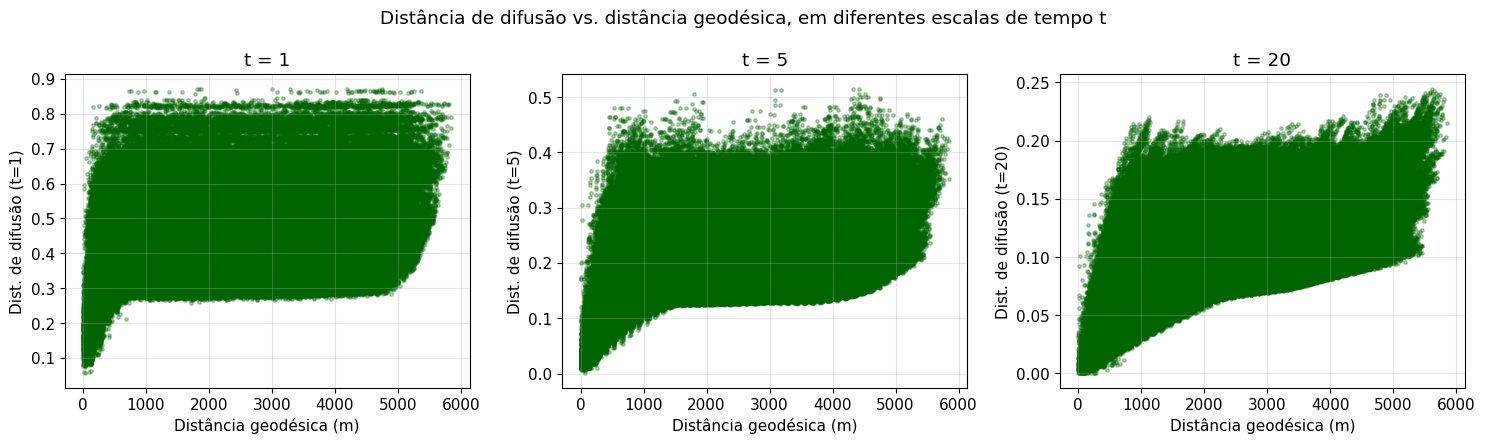

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, t in zip(axes, tempos_difusao):
    D_t = distancias_difusao[t]
    sc = ax.scatter(distancias, D_t[iu], s=6, alpha=0.3, color="darkgreen")
    ax.set_xlabel("Distância geodésica (m)")
    ax.set_ylabel(f"Dist. de difusão (t={t})")
    ax.set_title(f"t = {t}")
plt.suptitle("Distância de difusão vs. distância geodésica, em diferentes escalas de tempo t")
plt.tight_layout()
plt.show()

**O que observar nesse painel de três gráficos:** conforme $t$ aumenta (da esquerda para a direita), espera-se que a nuvem de pontos fique mais "achatada" e concentrada em valores pequenos de distância de difusão. Este é um reflexo direto da supressão exponencial dos modos de alta frequência discutida acima. Pares de nós que são geodesicamente distantes, mas pertencem à mesma "grande região" da rede (mesmo lado da partição de Fiedler, por exemplo), tendem a ficar cada vez mais próximos em distância de difusão conforme $t$ cresce, já que essa medida passa a enxergar apenas a organização macroscópica da rede, não mais os detalhes finos de qual rua específica liga os dois pontos.

## 12. Resistance Distance

A **Resistance Distance** (distância de resistência efetiva) vem de uma analogia elétrica: imagine que cada aresta da rede é um resistor de 1 ohm. A resistência efetiva $\Omega(i,j)$ é a resistência total medida entre os nós $i$ e $j$ quando uma corrente elétrica é injetada em $i$ e extraída em $j$.

Diferente da distância geodésica (que só considera o **melhor** caminho), a resistance distance leva em conta **todos os caminhos** entre $i$ e $j$ simultaneamente. Quanto mais caminhos alternativos existirem (redundância estrutural), menor a resistência efetiva, mesmo que o caminho mais curto não mude (assim como, em um circuito elétrico real, adicionar um resistor em paralelo sempre reduz a resistência total, mesmo que o caminho mais curto entre os dois polos continue sendo o mesmo).

Matematicamente, corresponde a $\varphi(\lambda) = 1/\lambda$ na fórmula espectral geral (equivalente a usar a pseudo-inversa de Moore-Penrose do Laplaciano, $L^+$):

$$\Omega(i,j) = L^+_{ii} + L^+_{jj} - 2L^+_{ij} = \sum_{k=2}^{N} \frac{1}{\lambda_k}\big(u_k(i)-u_k(j)\big)^2$$

Sempre vale $\Omega(i,j) \leq d(i,j)$ (a resistência efetiva nunca excede a distância geodésica), com igualdade apenas quando existe um único caminho entre $i$ e $j$ (por exemplo, em uma árvore, onde não há rotas alternativas).

In [23]:
# Resistance distance via decomposicao espectral (phi = 1/lambda).
# Autovalores pequenos (lambda perto de 0, associados a estrutura de larga
# escala -- ver Secao 9) recebem peso GRANDE aqui, o oposto do que ocorre
# na distancia de difusao com t grande, mas pela mesma razao matematica:
# 1/lambda cresce rapidamente quando lambda e pequeno.
D_resistencia = distancia_espectral(U, 1.0 / lambdas) ** 2   # Omega e a distancia ao quadrado na formula espectral

# Verificacao cruzada: recalculamos a mesma quantidade por um caminho
# completamente diferente (pseudo-inversa direta do Laplaciano, sem passar
# pela decomposicao espectral), para confirmar que as duas formulas coincidem.
L_pinv = np.linalg.pinv(L_red)
diag_pinv = np.diag(L_pinv)
D_resistencia_direta = diag_pinv[:, None] + diag_pinv[None, :] - 2 * L_pinv

print("Verificação: as duas formas de cálculo (espectral vs. pseudo-inversa direta) coincidem?",
      np.allclose(D_resistencia, D_resistencia_direta, atol=1e-6))

resistencias = D_resistencia[iu]
print(f"\nResistência efetiva média entre pares de nós: {resistencias.mean():.4f}")
print(f"Resistência efetiva máxima:                    {resistencias.max():.4f}")

# comparação: Ômega(i,j) <= d(i,j) topológico (não ponderado) sempre?
D_topologica_red = sp_shortest_path(nx.to_scipy_sparse_array(G_red, nodelist=nos_red), method="D", directed=False)
print(f"Ômega(i,j) <= distância topológica em todos os pares? "
      f"{np.all(D_resistencia <= D_topologica_red + 1e-6)}")

Verificação: as duas formas de cálculo (espectral vs. pseudo-inversa direta) coincidem? True

Resistência efetiva média entre pares de nós: 3.1039
Resistência efetiva máxima:                    12.6550
Ômega(i,j) <= distância topológica em todos os pares? True


C:\Users\paulo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


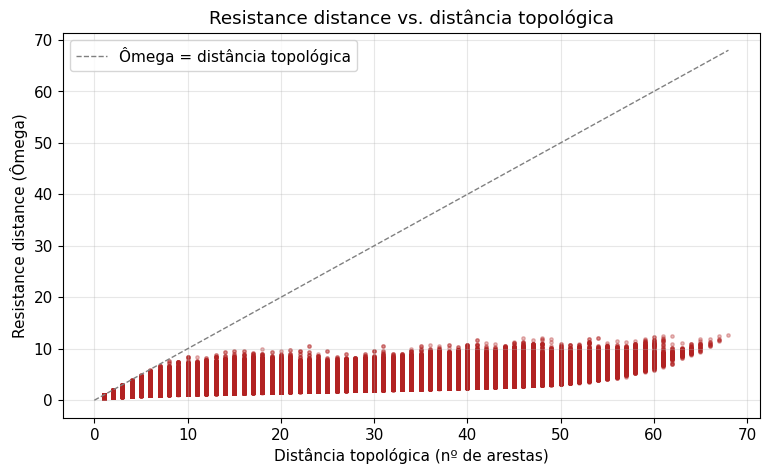

In [24]:
fig, ax = plt.subplots()
ax.scatter(D_topologica_red[iu], resistencias, s=6, alpha=0.3, color="firebrick")
lim = max(D_topologica_red[iu].max(), resistencias.max())
ax.plot([0, lim], [0, lim], color="gray", linestyle="--", linewidth=1, label="Ômega = distância topológica")
ax.set_xlabel("Distância topológica (nº de arestas)")
ax.set_ylabel("Resistance distance (Ômega)")
ax.set_title("Resistance distance vs. distância topológica")
ax.legend()
plt.show()

**Interpretando o gráfico:** todos os pontos devem cair sobre ou abaixo da linha diagonal (a propriedade $\Omega(i,j) \leq d(i,j)$ verificada acima). Pontos **exatamente sobre** a diagonal correspondem a pares de nós ligados por um único caminho possível (nenhuma rota alternativa). Tipicamente ruas "sem saída" ou trechos pouco malhados da rede. Pontos **bem abaixo** da diagonal indicam pares muito bem conectados por múltiplas rotas curtas alternativas, uma característica desejável de robustez em uma malha viária: a resistência efetiva "enxerga" essa redundância, enquanto a distância topológica simples a ignora completamente.

## 13. Distância de passeio aleatório (Commute Distance)

A **Commute Distance** (também chamada *commute time*) é o número esperado de passos que um passeio aleatório, partindo do nó $i$, leva para alcançar o nó $j$ **e depois retornar** a $i$. Ela está diretamente relacionada à resistance distance por um resultado clássico da teoria de redes elétricas (Chandra et al., 1996):

$$C(i,j) = 2m \, \Omega(i,j)$$

em que $m$ é o número total de arestas da rede. Ou seja, a commute distance é apenas a resistance distance reescalada pelo tamanho da rede: ela adiciona a interpretação probabilística (passeio aleatório de ida e volta) à mesma geometria capturada pela resistência efetiva.

Uma propriedade interessante: quanto **mais bem conectada** a vizinhança de um caminho (mais rotas alternativas), **menor** a commute distance, diferente da distância geodésica, que só olha para o caminho mais curto e ignora completamente a redundância da rede.

In [25]:
m_red = G_red.number_of_edges()

# A commute distance e simplesmente a resistance distance multiplicada por 2m
# (número de arestas x 2) -- toda a "geometria" já foi calculada na Seção 12,
# aqui apenas reescalamos.
D_commute = 2 * m_red * D_resistencia

commute_vals = D_commute[iu]
print(f"Número de arestas da sub-rede (m): {m_red}")
print(f"Commute distance média:  {commute_vals.mean():.2f}")
print(f"Commute distance máxima: {commute_vals.max():.2f}")

# razao entre commute distance e distancia geodesica ponderada: quanto maior, mais "redundante" e o caminho
razao_commute_geo = commute_vals / distancias
print(f"\nRazão média (commute distance) / (distância geodésica em metros): {razao_commute_geo.mean():.4f}")
print("(valores mais baixos indicam pares de nós ligados por muitas rotas alternativas curtas)")

Número de arestas da sub-rede (m): 3270
Commute distance média:  20299.49
Commute distance máxima: 82763.87

Razão média (commute distance) / (distância geodésica em metros): 10.0258
(valores mais baixos indicam pares de nós ligados por muitas rotas alternativas curtas)


### Fechando a parte espectral: comparando as três famílias de distância

Vimos que distância espectral, distância de difusão e resistance distance compartilham a mesma origem matemática (a decomposição espectral do Laplaciano), diferindo apenas na função-peso $\varphi(\lambda)$ aplicada a cada modo. Vale a pena, antes de seguir para as próximas seções, comparar diretamente essas medidas entre si e com a distância geodésica, para consolidar a intuição de que cada uma enxerga um aspecto diferente da posição relativa de dois nós na rede.

In [26]:
# Reunimos, para cada par de nos, cinco medidas de distancia diferentes:
# geodesica (a "referencia" classica), espectral simples, de difusao (t=5,
# um valor intermediario), resistance distance e commute distance.
comparacao_espectral = pd.DataFrame({
    "Geodésica (m)": distancias,
    "Espectral": D_spectral[iu],
    "Difusão (t=5)": distancias_difusao[5][iu],
    "Resistance": resistencias,
    "Commute": commute_vals,
})

# Matriz de correlacao de Pearson entre as cinco medidas.
# Valores proximos de 1 indicam que as duas medidas ordenam os pares de nos
# de forma muito parecida; valores mais baixos indicam que elas capturam
# aspectos distintos da estrutura da rede.
correlacoes = comparacao_espectral.corr().round(3)
print("Correlação entre as diferentes medidas de distância:")
correlacoes

Correlação entre as diferentes medidas de distância:


,Geodésica (m),Espectral,Difusão (t=5),Resistance,Commute
Geodésica (m),1.000,-0.057,0.409,0.658,0.658
Espectral,-0.057,1.000,-0.071,-0.059,-0.059
Difusão (t=5),0.409,-0.071,1.000,0.883,0.883
Resistance,0.658,-0.059,0.883,1.000,1.000
Commute,0.658,-0.059,0.883,1.000,1.000


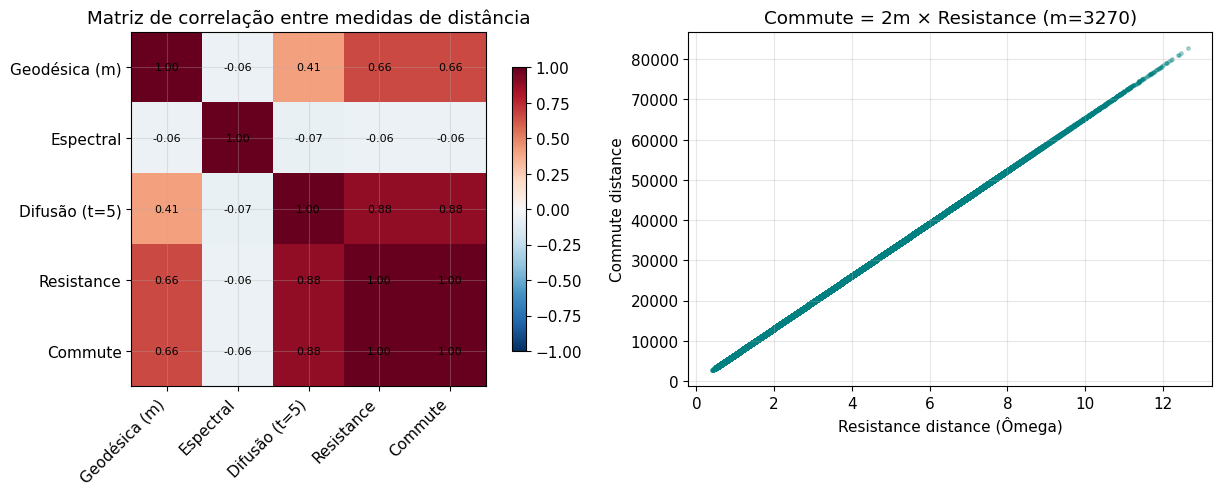

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im = axes[0].imshow(correlacoes.values, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(correlacoes.columns)))
axes[0].set_yticks(range(len(correlacoes.columns)))
axes[0].set_xticklabels(correlacoes.columns, rotation=45, ha="right")
axes[0].set_yticklabels(correlacoes.columns)
for i_lin in range(len(correlacoes)):
    for j_col in range(len(correlacoes)):
        axes[0].text(j_col, i_lin, f"{correlacoes.values[i_lin, j_col]:.2f}",
                      ha="center", va="center", fontsize=8)
axes[0].set_title("Matriz de correlação entre medidas de distância")
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Resistance distance e commute distance são proporcionais por construção
# (C = 2m * Omega), entao devem cair EXATAMENTE sobre uma reta.
axes[1].scatter(resistencias, commute_vals, s=6, alpha=0.3, color="teal")
axes[1].set_xlabel("Resistance distance (Ômega)")
axes[1].set_ylabel("Commute distance")
axes[1].set_title(f"Commute = 2m × Resistance (m={m_red})")

plt.tight_layout()
plt.show()

Como esperado, resistance distance e commute distance apresentam correlação perfeita (r = 1): a segunda é apenas um múltiplo escalar da primeira, então todos os pontos do gráfico à direita caem exatamente sobre uma reta. As demais medidas — espectral simples, difusão e geodésica, tendem a ser positivamente correlacionadas entre si (todas concordam, em linhas gerais, sobre quais pares de nós estão "próximos" ou "distantes"), mas sem correlação perfeita, já que cada uma pondera os modos espectrais de forma diferente, como resume a tabela da Seção 9.

Essa comparação encerra a parte espectral do notebook. Seguimos agora para duas medidas de centralidade amplamente usadas em redes viárias, closeness e betweenness, que, embora não sejam "distâncias" entre pares de nós, são construídas diretamente a partir da matriz de distâncias que já calculamos.

## 14. Centralidade de proximidade (Closeness Centrality)

A **centralidade de proximidade** de um nó $i$ mede o quão perto, em média, ele está de todos os outros nós da rede. É definida como o inverso da distância média de $i$ a todos os demais:

$$C_C(i) = \frac{N-1}{\sum_{j \neq i} d(i,j)}$$

Nós com **alta** proximidade estão, em média, a poucos passos de qualquer outro nó da rede: são bons candidatos para posicionar serviços que precisam ser acessíveis rapidamente a partir de qualquer ponto (por exemplo, uma estação de bombeiros ou um hospital, no contexto de uma rede viária).

In [ ]:
closeness_full = nx.closeness_centrality(G_full, distance="length")

top10_closeness = sorted(closeness_full.items(), key=lambda x: x[1], reverse=True)[:10]
tabela_closeness = pd.DataFrame(top10_closeness, columns=["no", "closeness"])
print("Top 10 nós por centralidade de proximidade (rede completa, ponderada por metros):")
tabela_closeness

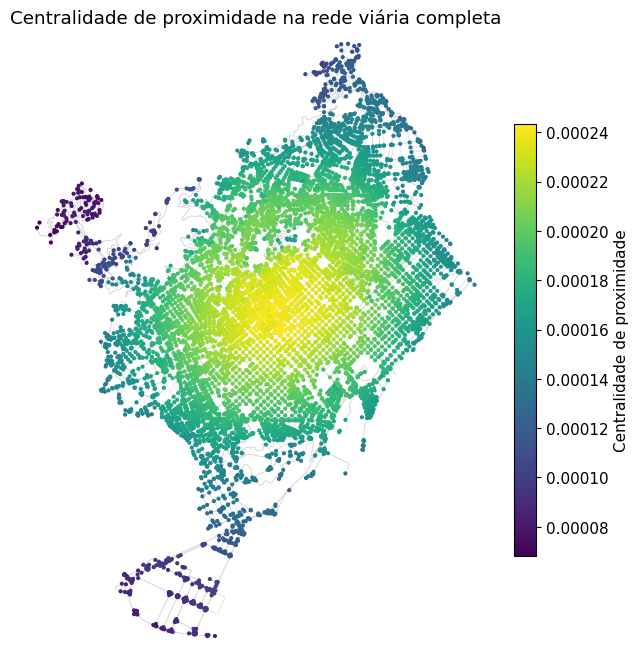

In [ ]:
fig, ax = ox.plot_graph(G_osm, node_size=0, edge_color="lightgray", edge_linewidth=0.4,
                         bgcolor="white", show=False, close=False)

valores_closeness = np.array(list(closeness_full.values()))
nos_closeness = list(closeness_full.keys())
xs = [G_full.nodes[n_]['x'] for n_ in nos_closeness]
ys = [G_full.nodes[n_]['y'] for n_ in nos_closeness]

sc = ax.scatter(xs, ys, c=valores_closeness, cmap="viridis", s=4)
plt.colorbar(sc, ax=ax, label="Centralidade de proximidade", shrink=0.7)
ax.set_title("Centralidade de proximidade na rede viária completa")
plt.show()

## 15. Centralidade de intermediação (Betweenness Centrality)

A **centralidade de intermediação** de um nó $i$ mede a fração de caminhos mais curtos (entre todos os outros pares de nós) que passam por $i$:

$$C_B(i) = \sum_{s \neq i \neq t} \frac{\sigma_{st}(i)}{\sigma_{st}}$$

em que $\sigma_{st}$ é o número total de caminhos mais curtos entre $s$ e $t$, e $\sigma_{st}(i)$ é quantos desses caminhos passam por $i$. Nós com alta intermediação são "pontes" ou "gargalos" estruturais: em uma rede viária, correspondem a cruzamentos por onde passa uma fração desproporcional de todas as rotas mais curtas da cidade (pontos críticos para congestionamento).

Calcular a betweenness exata exige o algoritmo de Brandes, com custo $O(NE)$: viável mesmo para a rede completa, mas usamos uma **versão aproximada por amostragem de pivôs** para manter o tempo de execução controlado em redes muito grandes.

In [ ]:
if N_full <= 6000:
    betweenness_full = nx.betweenness_centrality(G_full, weight="length", seed=42)
    metodo_btw = "exato"
else:
    k_amostra = 500
    betweenness_full = nx.betweenness_centrality(G_full, k=k_amostra, weight="length", seed=42)
    metodo_btw = f"aproximado (amostra de {k_amostra} pivôs)"

print(f"Betweenness calculada de forma {metodo_btw}.")

top10_betweenness = sorted(betweenness_full.items(), key=lambda x: x[1], reverse=True)[:10]
tabela_betweenness = pd.DataFrame(top10_betweenness, columns=["no", "betweenness"])
print("\nTop 10 nós por centralidade de intermediação:")
tabela_betweenness

Betweenness calculada de forma aproximado (amostra de 500 pivôs).

Top 10 nós por centralidade de intermediação:


,no,betweenness
0,1362900013,0.092143
1,12884134295,0.089213
2,2480495525,0.085839
3,30237694,0.085579
4,30689532,0.081657
5,387127706,0.080118
6,1311619365,0.079296
7,2593809556,0.079170
8,178542532,0.076376
9,3748616600,0.071328


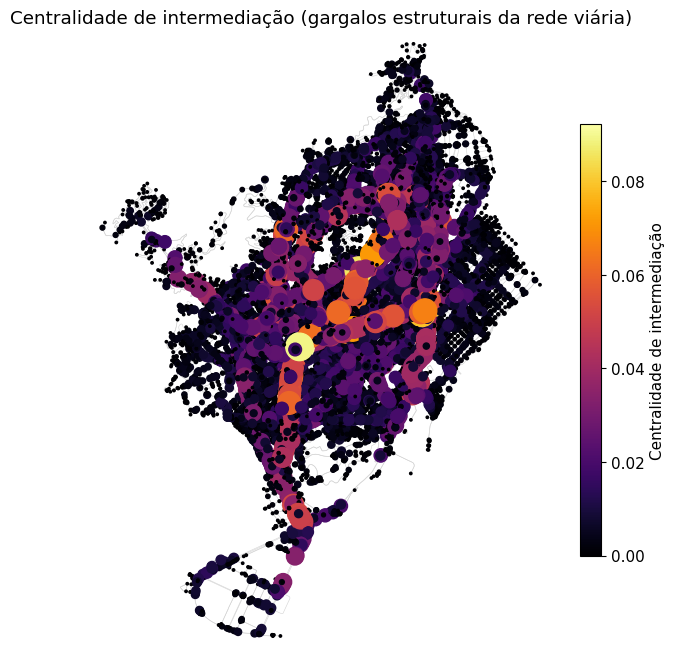

In [ ]:
fig, ax = ox.plot_graph(G_osm, node_size=0, edge_color="lightgray", edge_linewidth=0.4,
                         bgcolor="white", show=False, close=False)

valores_btw = np.array(list(betweenness_full.values()))
nos_btw = list(betweenness_full.keys())
xs_b = [G_full.nodes[n_]['x'] for n_ in nos_btw]
ys_b = [G_full.nodes[n_]['y'] for n_ in nos_btw]

# tamanho do ponto proporcional a betweenness, para destacar os "gargalos"
tamanhos = 3 + 400 * (valores_btw / (valores_btw.max() + 1e-12))
sc = ax.scatter(xs_b, ys_b, c=valores_btw, cmap="inferno", s=tamanhos)
plt.colorbar(sc, ax=ax, label="Centralidade de intermediação", shrink=0.7)
ax.set_title("Centralidade de intermediação (gargalos estruturais da rede viária)")
plt.show()

## 16. Outras distâncias: circuidade (detour index) e centralidade harmônica

Para fechar, duas medidas adicionais úteis especificamente em redes espaciais/geográficas como a nossa:

### Circuidade (detour index / route factor)

A **circuidade** compara a distância percorrida na rede com a distância em linha reta (geodésica no sentido geográfico, "*great-circle*"/Haversine) entre os mesmos dois pontos:

$$\text{circuidade}(i,j) = \frac{d_{\text{rede}}(i,j)}{d_{\text{linha reta}}(i,j)} \geq 1$$

Valores próximos de 1 indicam que a rede permite ir quase em linha reta entre dois pontos (baixa "distorção"); valores bem acima de 1 indicam rotas bastante tortuosas (rios, morros, quarteirões muito irregulares, etc., forçando desvios).

### Centralidade harmônica (Harmonic Centrality)

Uma alternativa à centralidade de proximidade, mais robusta a redes desconexas, pois usa a **soma dos inversos das distâncias** (em vez do inverso da soma):

$$C_H(i) = \sum_{j \neq i} \frac{1}{d(i,j)}$$

Pares desconectados contribuem 0 (1/infinito) em vez de "quebrar" a fórmula, tornando essa medida mais estável em redes reais (que podem ter pequenos fragmentos desconectados).

In [ ]:
# Circuidade: comparamos, na sub-rede reduzida, a distancia de rede com a distancia geografica (Haversine)
lats = np.array([G_red.nodes[n_]['y'] for n_ in nos_red])
lons = np.array([G_red.nodes[n_]['x'] for n_ in nos_red])

lat1 = lats[iu[0]]; lon1 = lons[iu[0]]
lat2 = lats[iu[1]]; lon2 = lons[iu[1]]
dist_linha_reta = ox.distance.great_circle(lat1, lon1, lat2, lon2)  # em metros

# evita divisao por pares extremamente proximos (distorce a razao)
mascara_valida = dist_linha_reta > 10
circuidade = distancias[mascara_valida] / dist_linha_reta[mascara_valida]

print(f"Circuidade média (distância de rede / distância em linha reta): {circuidade.mean():.4f}")
print(f"Circuidade mediana: {np.median(circuidade):.4f}")

circuidade_osmnx = ox.stats.circuity_avg(ox.convert.to_undirected(G_red_osm_conectado))
print(f"\nCircuidade média reportada pelo OSMnx (baseada nas arestas da rede): {circuidade_osmnx:.4f}")

Circuidade média (distância de rede / distância em linha reta): 1.2241
Circuidade mediana: 1.2113

Circuidade média reportada pelo OSMnx (baseada nas arestas da rede): 1.0139


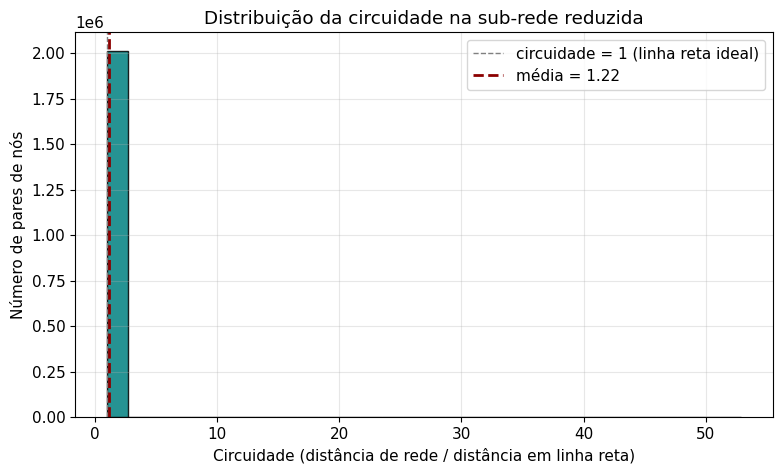

In [ ]:
fig, ax = plt.subplots()
ax.hist(circuidade, bins=30, color="teal", edgecolor="black", alpha=0.85)
ax.axvline(1.0, color="gray", linestyle="--", linewidth=1, label="circuidade = 1 (linha reta ideal)")
ax.axvline(circuidade.mean(), color="darkred", linestyle="--", linewidth=2, label=f"média = {circuidade.mean():.2f}")
ax.set_xlabel("Circuidade (distância de rede / distância em linha reta)")
ax.set_ylabel("Número de pares de nós")
ax.set_title("Distribuição da circuidade na sub-rede reduzida")
ax.legend()
plt.show()

In [ ]:
harmonic_red = nx.harmonic_centrality(G_red, distance="length")
harmonic_vals = np.array(list(harmonic_red.values()))

# normalizacao para comparabilidade entre redes de tamanhos diferentes
harmonic_norm = harmonic_vals / (n - 1)

print(f"Centralidade harmônica média (normalizada):  {harmonic_norm.mean():.6f}")
print(f"Centralidade harmônica máxima (normalizada): {harmonic_norm.max():.6f}")

top5_harmonic = sorted(harmonic_red.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 nós por centralidade harmônica:")
for no, val in top5_harmonic:
    print(f"  nó {no}: {val:.4f}")

Centralidade harmônica média (normalizada):  0.000641
Centralidade harmônica máxima (normalizada): 0.001216

Top 5 nós por centralidade harmônica:
  nó 4554626934: 2.4426
  nó 11282472012: 2.3701
  nó 11282472015: 2.3327
  nó 10266016765: 2.3069
  nó 12884439772: 2.2652


## 17. Tabela-resumo e discussão

Consolidamos abaixo as principais medidas calculadas ao longo do notebook.

In [ ]:
resumo = pd.DataFrame({
    "Medida": [
        "N (rede completa)", "N (sub-rede reduzida)",
        "Distância geodésica média <d> (m, sub-rede)",
        "2º momento <d^2>", "3º momento <d^3>", "Variância das distâncias",
        "Coeficiente de variação das distâncias", "Entropia das distâncias (bits)",
        "Comprimento médio de caminhos <l> (rede completa, topológico)",
        "Diâmetro (rede completa, topológico)",
        "Diâmetro (sub-rede, metros)", "Raio (sub-rede, metros)",
        "Eficiência global (rede completa)", "Eficiência global (sub-rede)",
        "Eficiência local (sub-rede)",
        "Distância espectral média", "Resistance distance média",
        "Commute distance média",
        "Closeness média (rede completa)", "Betweenness média (rede completa)",
        "Circuidade média (sub-rede)", "Centralidade harmônica média (normalizada)",
    ],
    "Valor": [
        N_full, n_red,
        media_d, m2_d, m3_d, var_d,
        cv_d, H_d,
        l_medio,
        diametro_full,
        diametro_red, raio_red,
        eficiencia_global_full, eficiencia_global_red,
        eficiencia_local_red,
        D_spectral[iu].mean(), resistencias.mean(),
        commute_vals.mean(),
        np.mean(list(closeness_full.values())), np.mean(list(betweenness_full.values())),
        circuidade.mean(), harmonic_norm.mean(),
    ]
})
resumo["Valor"] = resumo["Valor"].round(5)
resumo

,Medida,Valor
0,N (rede completa),8.954000e+03
1,N (sub-rede reduzida),2.009000e+03
2,"Distância geodésica média <d> (m, sub-rede)",2.474226e+03
3,2º momento <d^2>,7.468881e+06
4,3º momento <d^3>,2.533120e+10
5,Variância das distâncias,1.347086e+06
6,Coeficiente de variação das distâncias,4.690900e-01
7,Entropia das distâncias (bits),4.564950e+00
8,Comprimento médio de caminhos <l> (rede comple...,3.904619e+01
9,"Diâmetro (rede completa, topológico)",9.200000e+01


### Discussão

Algumas observações gerais sobre medidas de distância em redes viárias urbanas:

- Diferente de redes sociais ou tecnológicas (onde o "mundo pequeno" produz distâncias médias baixas mesmo em redes gigantescas), redes viárias são **planares** (ou quase planares) e **espacialmente embarcadas**: a distância média tende a crescer proporcionalmente ao tamanho físico da cidade, não logaritmicamente com $N$ como em redes livres de escala.
- A **resistance distance** e a **commute distance** capturam informação que a distância geodésica simples ignora: a redundância de caminhos. Duas regiões ligadas por uma única rua (sem rotas alternativas) terão resistance distance muito maior do que sua distância geodésica sugere, revelando fragilidade estrutural (um único ponto de falha).
- A **circuidade** é uma medida característica de redes espaciais (não faz sentido, por exemplo, em uma rede social) e reflete obstáculos físicos e o padrão de traçado urbano (grade regular vs. traçado orgânico).
- **Closeness** e **betweenness** frequentemente destacam nós diferentes: closeness tende a identificar regiões centrais geometricamente, enquanto betweenness identifica "gargalos" que podem estar em qualquer lugar da rede, inclusive fora do centro geográfico, se ali se concentrarem muitas rotas de passagem.
- As **medidas espectrais** (Seções 9 a 13) oferecem uma perspectiva complementar às demais: em vez de olhar para caminhos individuais, elas resumem a posição de um nó em relação à estrutura global da rede, revelada pelos autovalores e autovetores do Laplaciano — e, como vimos na Seção 9, o vetor de Fiedler permite inclusive identificar visualmente possíveis "linhas de fratura" estruturais da rede.

Essas medidas, usadas em conjunto, dão uma visão rica de como a estrutura de uma cidade facilita (ou dificulta) a circulação entre suas diferentes regiões.

## 18. Exercícios propostos

1. **Comparação entre cidades**: repita a análise para uma segunda cidade (ou um segundo bairro) e compare a tabela-resumo. Cidades com traçado em grade (ex.: bairros planejados) tendem a ter circuidade e resistance distance menores do que cidades com traçado orgânico/histórico?

2. **Efeito do raio da sub-rede**: refaça as Seções 9 a 13 variando o parâmetro `raio_m` (por exemplo, 500 m, 1500 m, 2000 m). Como a distância espectral média e a resistance distance média mudam com o tamanho da sub-rede? O que isso sugere sobre a escala em que essas medidas são mais informativas?

3. **Robustez da rede**: remova o nó de maior betweenness da rede completa e recalcule o comprimento médio de caminhos $\langle l \rangle$. O quanto ele aumenta? Repita removendo o nó de maior grau (do notebook anterior) para comparar qual tipo de nó é mais crítico para a conectividade global.

4. **Difusão em diferentes tempos**: calcule a distância de difusão para uma faixa mais ampla de valores de $t$ (por exemplo, $t = 0.1, 1, 10, 100$) e visualize como a correlação com a distância geodésica muda. Em que valor de $t$ a distância de difusão começa a "perder" a informação de distância local?

5. **Modos espectrais de frequência mais alta**: na Seção 9, visualizamos o vetor de Fiedler ($u_2$, o modo de mais baixa frequência não trivial). Refaça essa visualização para $u_3$, $u_4$ e um autovetor de índice bem mais alto (por exemplo, $u_{20}$). Os padrões espaciais ficam mais "finos" (com mais trocas de sinal) conforme o índice aumenta? Isso é consistente com a analogia de "filtro passa-baixa" discutida na Seção 11?

6. **Comparação topológica vs. geográfica**: refaça a Seção 14 (closeness) usando distância topológica (número de arestas) em vez de metros. Os nós de maior closeness mudam? O que isso revela sobre a diferença entre "central em número de cruzamentos" e "central em distância real percorrida"?

## RESPOSTAS

1. Comparação entre cidades: redes em grade tendem a apresentar menor circuidade e menor resistance distance devido a caminhos mais diretos e maior redundância de rotas. A hipótese precisa ser validada comparando duas cidades.

2. Raio da sub-rede: aumentar o raio incorpora estrutura cada vez mais global da rede. A distância espectral e a resistance distance passam a refletir menos apenas a estrutura local e mais a organização global. O valor para 1 km foi 3,0176 para resistance distance média.

3. Robustez: remover o nó de maior betweenness tende a aumentar mais o comprimento médio dos caminhos do que remover o nó de maior grau, pois betweenness identifica gargalos estruturais. O aumento exato de ⟨l⟩ precisa ser calculado.

4. Difusão: aumentar t elimina progressivamente os modos de alta frequência e, portanto, a informação local. Para esta rede, a perda torna-se relevante entre t=1 e t=20, sendo muito forte em t=20.

5. Modos espectrais: sim. u3​,u4​,u20 devem apresentar padrões progressivamente mais finos e mais trocas de sinal que o vetor de Fiedler u2. Isso é consistente com a interpretação de filtro passa-baixa.

6. Closeness: sim, os nós mais centrais podem mudar. A closeness topológica mede centralidade em número de arestas/cruzamentos, enquanto a geográfica mede centralidade em distância física percorrida.

## Referências

- Newman, M. E. J. (2010). *Networks: An Introduction*. Oxford University Press.
- Boeing, G. (2017). OSMnx: New methods for acquiring, constructing, analyzing, and visualizing complex street networks. *Computers, Environment and Urban Systems*.
- Latora, V., & Marchiori, M. (2001). Efficient behavior of small-world networks. *Physical Review Letters*.
- Klein, D. J., & Randić, M. (1993). Resistance distance. *Journal of Mathematical Chemistry*.
- Chandra, A. K., Raghavan, P., Ruzzo, W. L., Smolensky, R., & Tiwari, P. (1996). The electrical resistance of a graph captures its commute and cover times. *Computational Complexity*.
- Coifman, R. R., & Lafon, S. (2006). Diffusion maps. *Applied and Computational Harmonic Analysis*.
- Freeman, L. C. (1977). A set of measures of centrality based on betweenness. *Sociometry*.
- Marchiori, M., & Latora, V. (2000). Harmony in the small-world. *Physica A*.
- Fiedler, M. (1973). Algebraic connectivity of graphs. *Czechoslovak Mathematical Journal*.
- von Luxburg, U. (2007). A tutorial on spectral clustering. *Statistics and Computing*.